In [19]:
import numpy as np
from scipy.io import loadmat

#data = np.loadtxt("PatientQM_01Clean.txt")
data_path = "/home/kslote/Desktop/epilepsy/data/E3Data.mat"
e3data = loadmat(data_path)


X = e3data["X1"].T
X_raw = X
X = (X - np.mean(X)) / np.std(X)
data = X.T


In [20]:
data.shape

(49972, 120)

In [ ]:
import numpy as np
import pandas as pd
from causationentropy.core import discover_network


start = 10000 # 49972 - 20000
end = None #40000
data_before_seizure = data.T[:, start:end]

# Discover causal network
network = discover_network(data_before_seizure.T, 
                           alpha_forward=0.001,
                           alpha_backward=0.001,
                           method='standard', max_lag=1)


Estimating edges for node 0 (X0)


In [ ]:
import matplotlib.pyplot as plt
plt.plot(data_before_seizure.T)

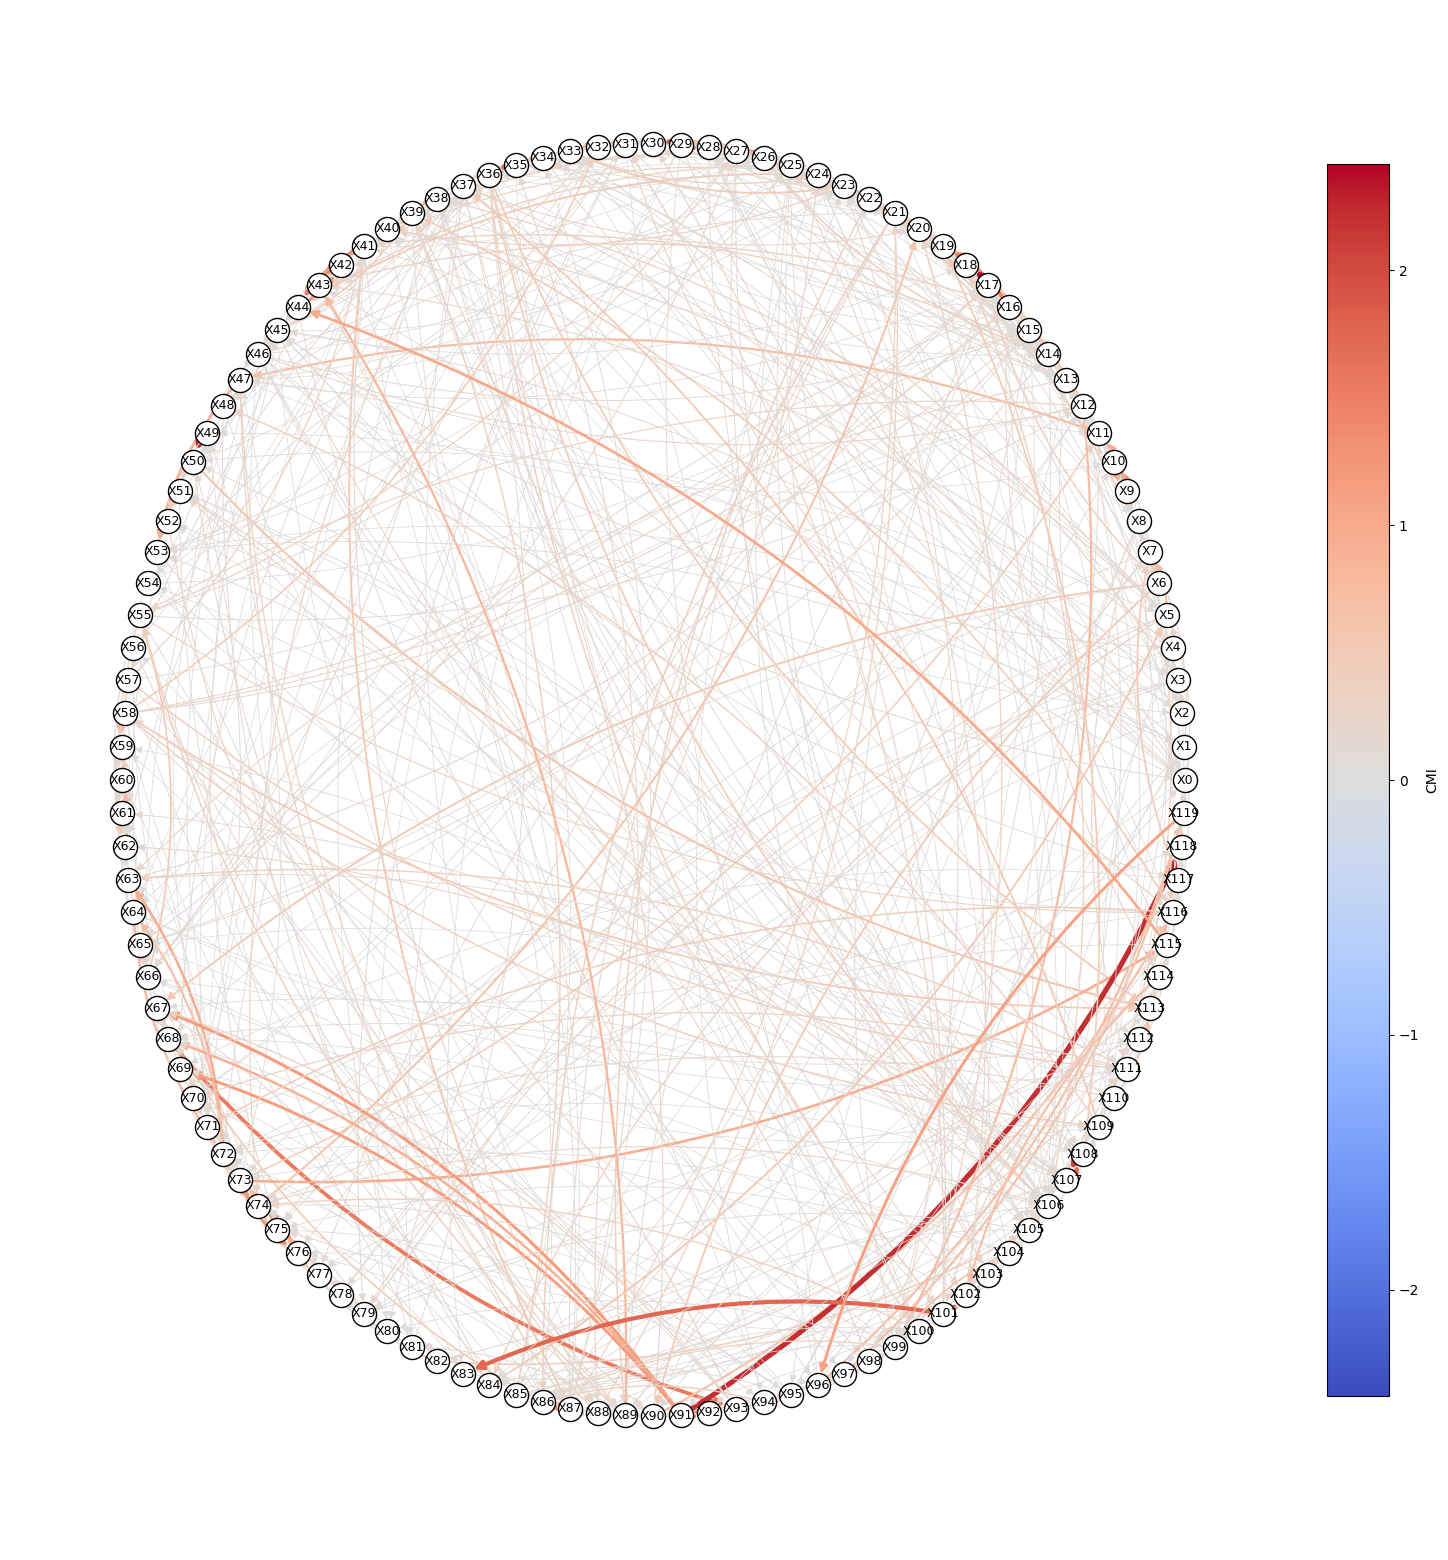

In [28]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

def plot_cmi_graph(G, layout="circular", node_size=300, figsize=(20,20),
                   edge_width_range=(0.5, 4.0), arrowstyle="-|>", arrowsize=12):
    # positions
    if layout == "circular":
        pos = nx.circular_layout(G)
    elif layout == "spring":
        pos = nx.spring_layout(G, seed=42)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.spectral_layout(G)

    # collect CMI values
    cmi_vals = np.array([float(data.get("cmi", 0.0)) for _,_,data in G.edges(data=True)])
    abs_cmi = np.abs(cmi_vals)

    # edge widths
    w_min, w_max = edge_width_range
    widths = w_min + (w_max - w_min) * (abs_cmi / abs_cmi.max() if abs_cmi.max() > 0 else 0)

    # color mapping
    cmap = mpl.colormaps.get_cmap("coolwarm")
    v = max(abs(cmi_vals.min()), abs(cmi_vals.max()))
    norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
    edge_colors = [cmap(norm(val)) for val in cmi_vals]

    # draw
    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="white",
                           edgecolors="black", linewidths=1.0, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
    nx.draw_networkx_edges(
        G, pos, edge_color=edge_colors, width=widths,
        arrows=True, arrowstyle=arrowstyle, arrowsize=arrowsize,
        connectionstyle="arc3,rad=0.15", ax=ax   # <-- curve
    )

    # colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.8, pad=0.02, label="CMI")

    ax.set_axis_off()
    plt.show()

plot_cmi_graph(network, layout="circular")

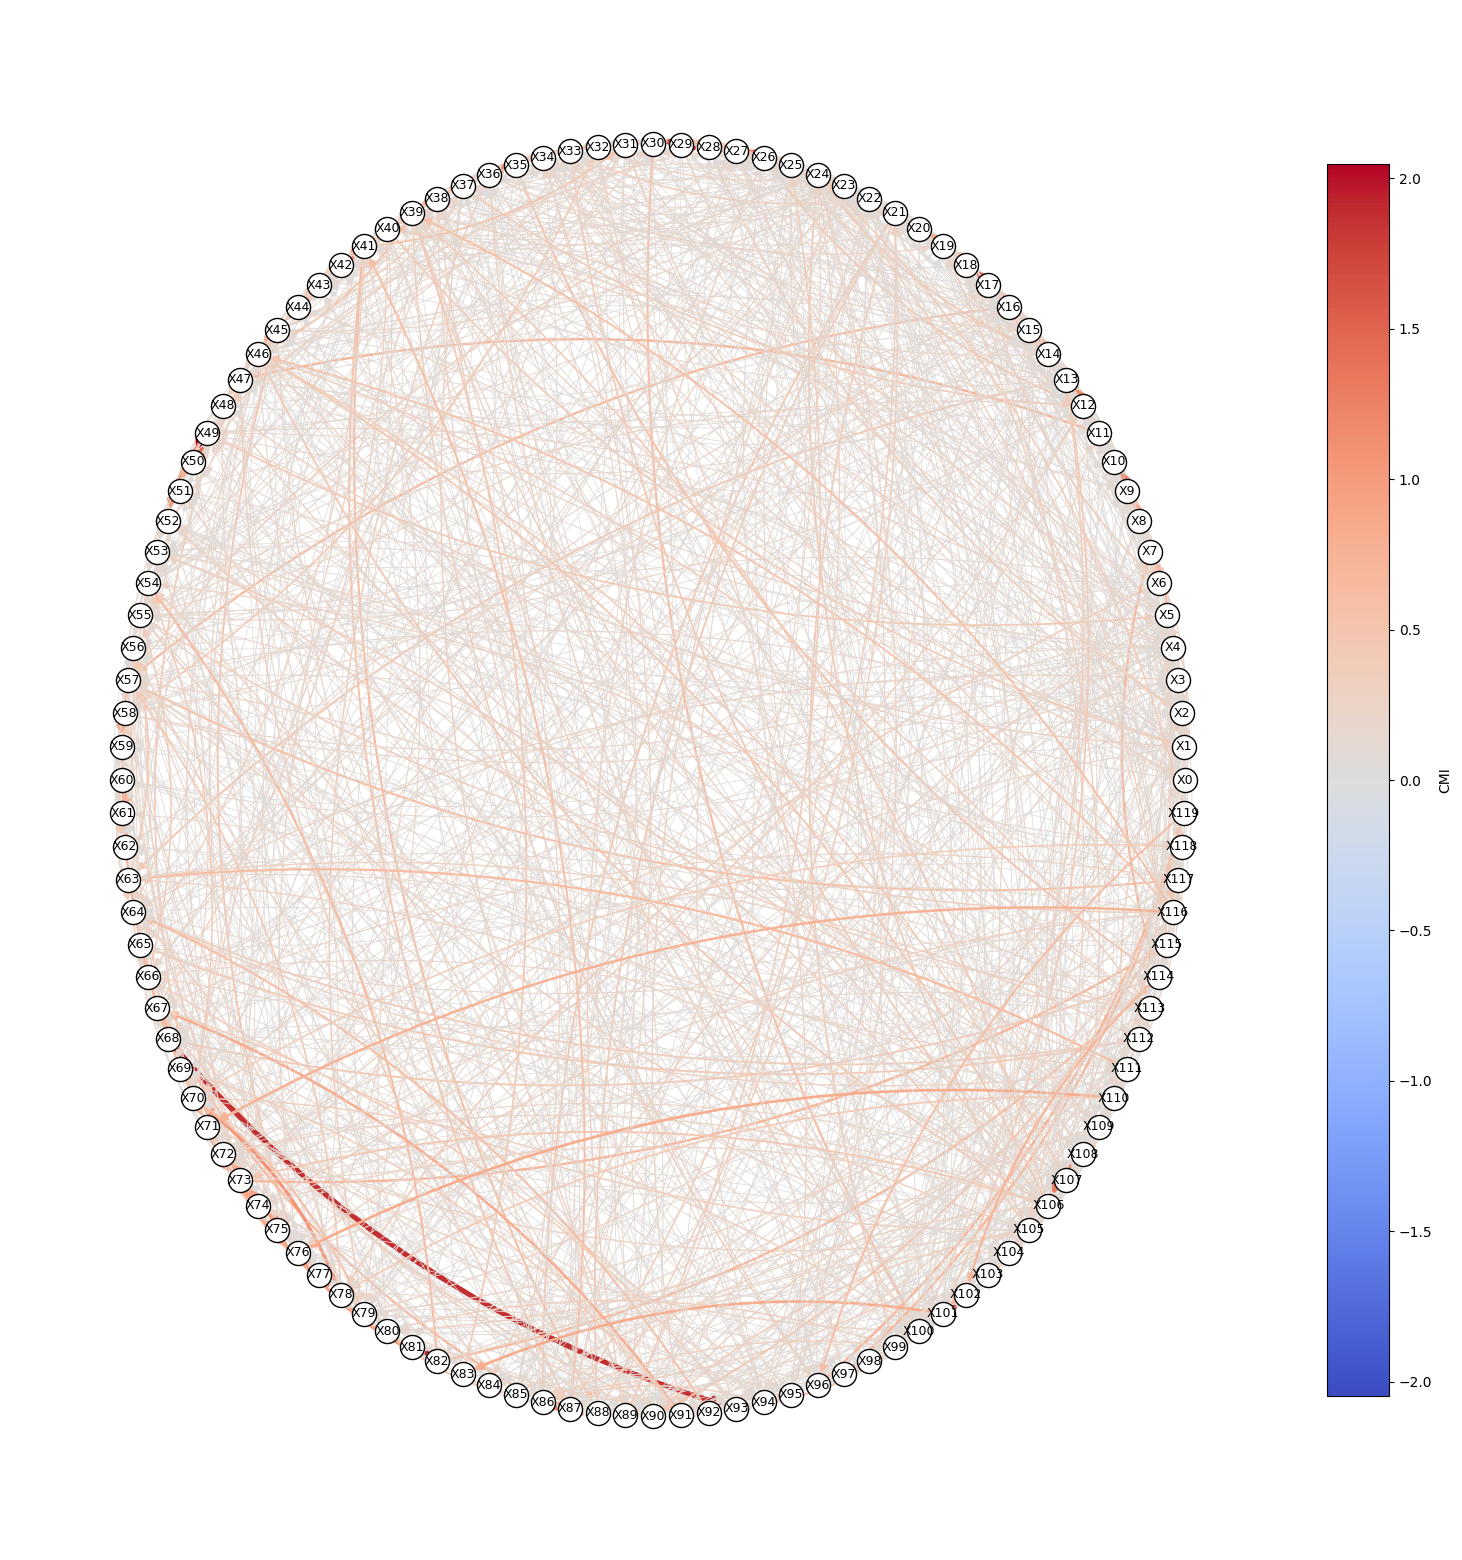

In [25]:
plot_cmi_graph(network, layout="circular")

In [9]:
import numpy as np

from tigramite.data_processing import DataFrame
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.pcmci import PCMCI

# data_before_seizure in your code is: data.T[:, start:end]  -> shape (vars, time)
# Tigramite expects array of shape (time, vars)
ts = data_before_seizure.T.astype(float)   # (T, N)

# Optional: standardize per variable (recommended if not already)
ts = (ts - ts.mean(axis=0, keepdims=True)) / ts.std(axis=0, keepdims=True)

# Build Tigramite dataframe
df_tig = DataFrame(ts)

# Conditional independence test: Partial Correlation
parcorr = ParCorr(significance='analytic')  # analytic p-values for ParCorr

# PCMCI+ setup
pcmci = PCMCI(dataframe=df_tig, cond_ind_test=parcorr, verbosity=1)

# Run PCMCI+:
# tau_min=0 includes instantaneous links; set tau_min=1 if you ONLY want lagged links.
results = pcmci.run_pcmciplus(
    tau_min=1,
    tau_max=1,       # max_lag=1 to match your causationentropy call
    pc_alpha=0.05    # PC step significance level; tune as needed
)

# Extract adjacency using an FDR-controlled threshold (optional but common)
# You can also threshold directly on p_matrix or q_matrix.
alpha_level = 0.05
q_matrix = pcmci.get_corrected_pvalues(results['p_matrix'], fdr_method='fdr_bh')
graph = pcmci.return_significant_links(
    p_matrix=q_matrix,
    val_matrix=results['val_matrix'],
    alpha_level=alpha_level
)

print("Tigramite PCMCI+ results keys:", results.keys())
print("Significant links (after FDR BH) at alpha =", alpha_level)
# pcmci.print_significant_links(
#     p_matrix=q_matrix,
#     val_matrix=results['val_matrix'],
#     alpha_level=alpha_level
# )

# `graph` contains the network structure; you can also use:
# results['graph']  (PCMCI+ internal graph representation)
# results['p_matrix'], results['val_matrix']



##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 1
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable 0 has 9 link(s):
        (0 -1): max_pval = 0.00000, |min_val| =  0.969
        (58 -1): max_pval = 0.00244, |min_val| =  0.030
        (62 -1): max_pval = 0.00266, |min_val| =  0.030
        (88 -1): max_pval = 0.00290, |min_val| =  0.030
        (48 -1): max_pval = 0.00434, |min_val| =  0.028
        (104 -1): max_pval = 0.00695, |min_val| =  0.027
        (97 -1): max_pval = 0.01019, |min_val| =  0.025
        (21 -1): max_pval = 0.03942, |min_val| =  0.020
        (43 -1): max_pval = 0.04166, |min_val| =  0.020

    Variable 1 has 13 link(s):
        (1 -1): max_pval = 0.00000, |min_val| =  0.986
        (23 -1): max_pval = 0.00000, |min_val| =  0.054
        (92 -1): max_pval = 0.00000, |min_val| =  0.046
        (22 -1): max_pval = 0.000

TypeError: PCMCI.return_significant_links() got an unexpected keyword argument 'p_matrix'

In [11]:
from causationentropy.graph import pcmci_to_networkx

G_pcmci = pcmci_to_networkx(results)

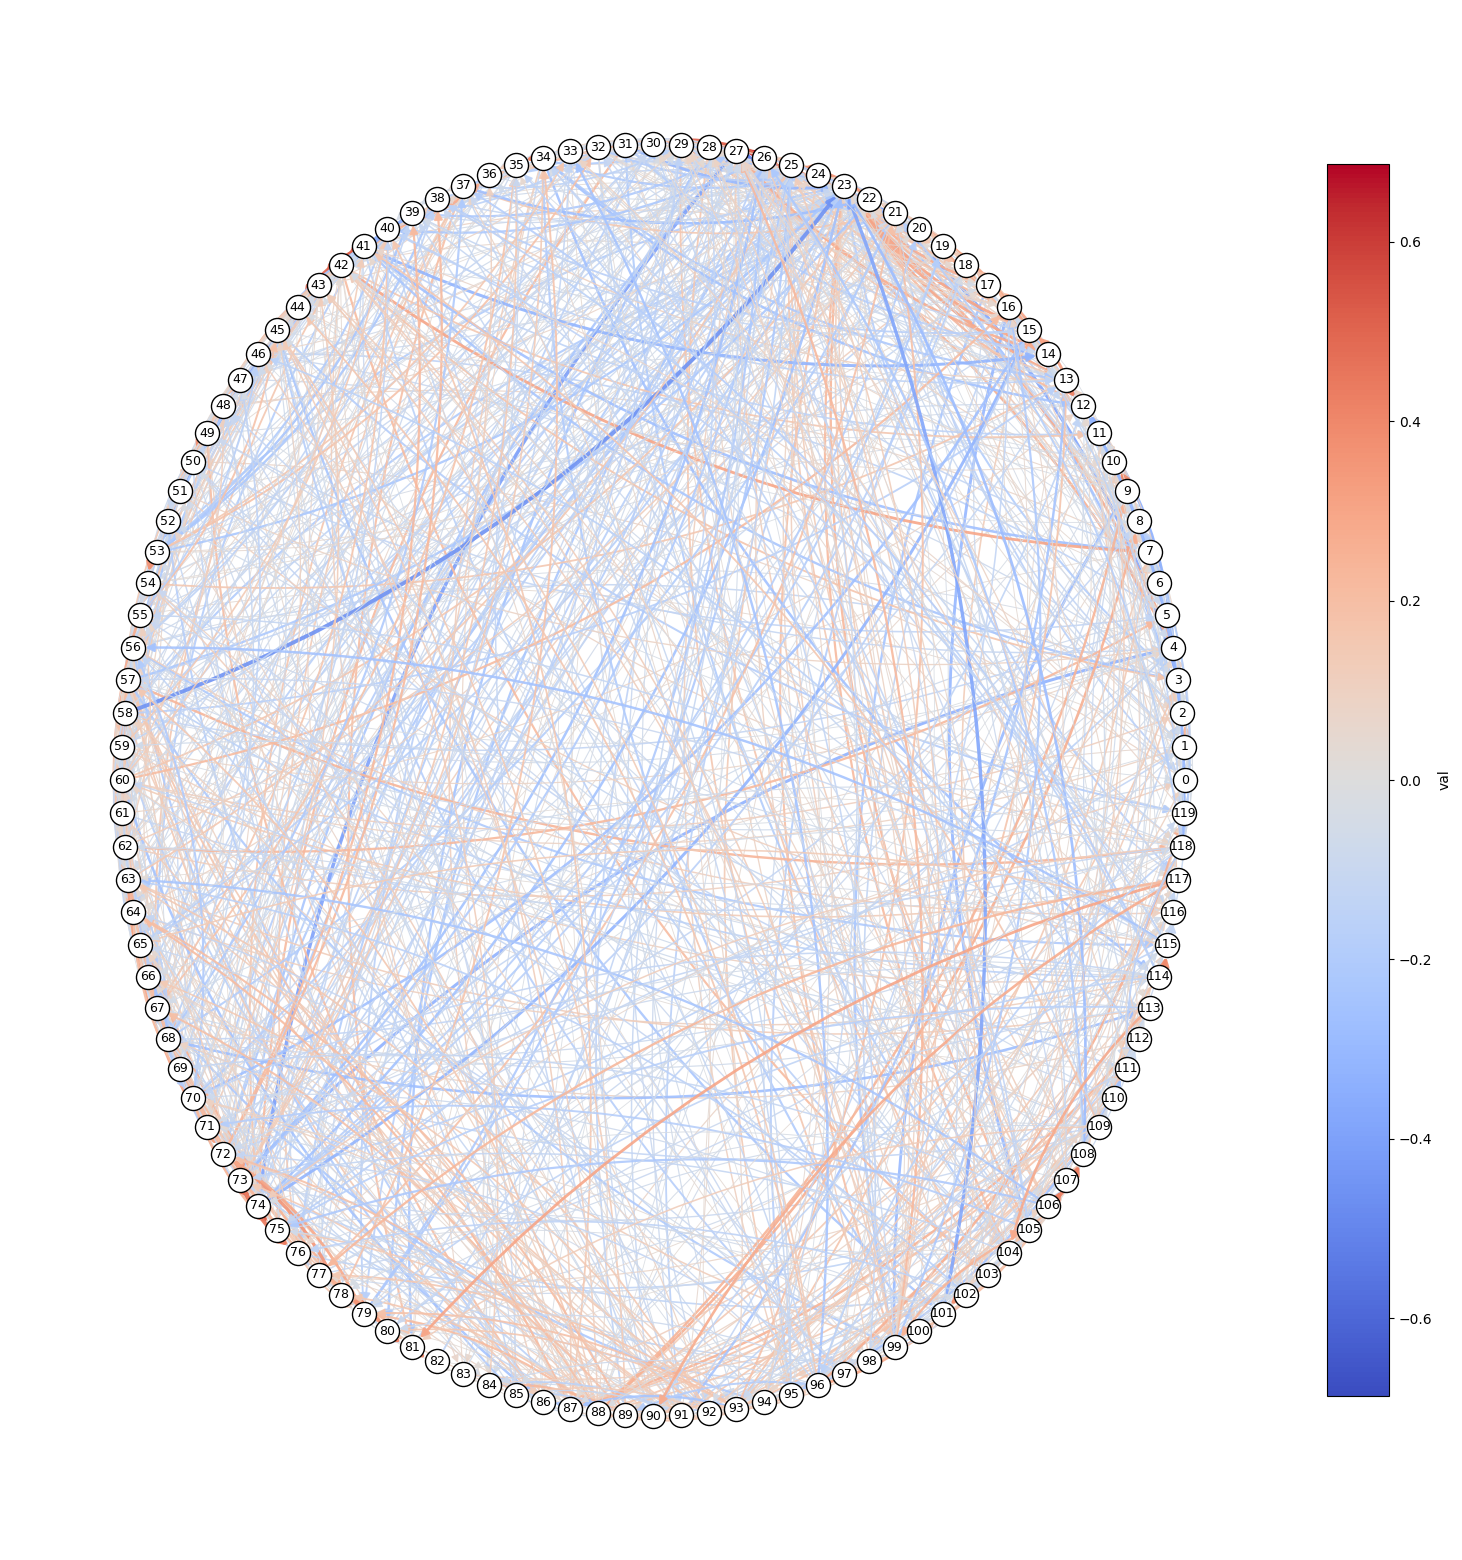

In [18]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

def plot_val_graph(
    G,
    layout="circular",
    value_attr="val",          # <-- uses your edge attribute
    node_size=300,
    figsize=(20, 20),
    edge_width_range=(0.5, 4.0),
    arrowstyle="-|>",
    arrowsize=12,
    curve_rad=0.15,            # curvature
    only_significant=False,    # optional filter by p_value
    alpha=0.9
):
    # positions
    if layout == "circular":
        pos = nx.circular_layout(G)
    elif layout == "spring":
        pos = nx.spring_layout(G, seed=42)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.spectral_layout(G)

    # --- collect edges + values (supports MultiGraphs) ---
    is_multi = G.is_multigraph()
    if is_multi:
        edges = list(G.edges(keys=True, data=True))
    else:
        edges = list(G.edges(data=True))

    # optional significance filter
    if only_significant:
        def keep(d):
            return float(d.get("p_value", 1.0)) < 0.05
        if is_multi:
            edges = [(u, v, k, d) for (u, v, k, d) in edges if keep(d)]
        else:
            edges = [(u, v, d) for (u, v, d) in edges if keep(d)]

    if len(edges) == 0:
        raise ValueError("No edges to plot (possibly filtered out).")

    # values
    if is_multi:
        vals = np.array([float(d.get(value_attr, 0.0)) for (_, _, _, d) in edges], dtype=float)
        edgelist = [(u, v, k) for (u, v, k, _) in edges]
    else:
        vals = np.array([float(d.get(value_attr, 0.0)) for (_, _, d) in edges], dtype=float)
        edgelist = [(u, v) for (u, v, _) in edges]

    abs_vals = np.abs(vals)

    # edge widths
    w_min, w_max = edge_width_range
    denom = abs_vals.max()
    widths = w_min + (w_max - w_min) * (abs_vals / denom if denom > 0 else 0.0)

    # color mapping centered at 0
    cmap = mpl.colormaps.get_cmap("coolwarm")
    v = float(max(abs(vals.min()), abs(vals.max()))) if len(vals) else 1.0
    if v == 0:
        v = 1.0
    norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
    edge_colors = [cmap(norm(x)) for x in vals]

    # draw
    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_size,
        node_color="white",
        edgecolors="black",
        linewidths=1.0,
        ax=ax
    )
    nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)

    nx.draw_networkx_edges(
        G, pos,
        edgelist=edgelist,             # <-- important for MultiGraphs
        edge_color=edge_colors,
        width=widths,
        arrows=True,
        arrowstyle=arrowstyle,
        arrowsize=arrowsize,
        connectionstyle=f"arc3,rad={curve_rad}",
        alpha=alpha,
        ax=ax
    )

    # colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.8, pad=0.02, label=value_attr)

    ax.set_axis_off()
    plt.show()

G_pcmci.remove_edges_from([(u, v, k) for u, v, k in G_pcmci.edges(keys=True) if u == v])
plot_val_graph(G_pcmci, layout="circular", only_significant=True)  

In [ ]:
G_pcmci.edges(data=True)

In [ ]:
start = 49972 - 20000
end = 40000
data_splice = data.T[:, start:end]

In [7]:
import causationentropy
dir(causationentropy)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'core',
 'datasets',
 'discovery',
 'estimators',
 'synthetic',
 'tests']